In [2]:
# Clone the repository
!git clone https://github.com/CristylePGarrard/Fiverr-consulting-toolkit.git
%cd Fiverr-consulting-toolkit

import pandas as pd

# Load the cleaned dataset we engineered in notebook 1
df = pd.read_csv('data/processed/cleaned_fiverr_dataset.csv')
print(f"Loaded Cleaned Dataset! Total Rows to Analyze: {len(df)}")


Cloning into 'Fiverr-consulting-toolkit'...
remote: Enumerating objects: 44, done.
remote: Counting objects: 100% (44/44), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 44 (delta 12), reused 17 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (44/44), 116.82 KiB | 2.25 MiB/s, done.
Resolving deltas: 100% (12/12), done.
/content/Fiverr-consulting-toolkit
Loaded Cleaned Dataset! Total Rows to Analyze: 83


In [3]:
# Calculate basic text metrics for the gig descriptions
df['gig_desc_char_count'] = df['about_gig'].astype(str).str.len()
df['gig_desc_word_count'] = df['about_gig'].astype(str).apply(lambda x: len(x.split()))

# Display statistical breakdown of text length
print("--- Gig Description Word Count Distribution ---")
print(df['gig_desc_word_count'].describe())


--- Gig Description Word Count Distribution ---
count     83.000000
mean     161.108434
std       36.475856
min       73.000000
25%      146.000000
50%      174.000000
75%      183.000000
max      218.000000
Name: gig_desc_word_count, dtype: float64


In [4]:
from collections import Counter
import re

def extract_top_keywords(text_series, num_keywords=20):
    """Cleans text data and extracts the most common meaningful words."""
    # List of common English stop words to filter out
    stop_words = set([
        'the', 'and', 'to', 'a', 'in', 'for', 'of', 'i', 'you', 'is', 'that', 'this',
        'with', 'on', 'your', 'my', 'will', 'an', 'as', 'are', 'be', 'at', 'or', 'it',
        'from', 'by', 'have', 'can', 'with', 'about', 'me', 'our', 'we', 'all', 'if'
    ])

    all_words = []

    for text in text_series.dropna().astype(str):
        # Remove punctuation and lowercase everything
        clean_text = re.sub(r'[^\w\s]', '', text.lower())
        # Split into individual words
        words = clean_text.split()
        # Filter out numbers and generic stop words
        filtered_words = [w for w in words if w not in stop_words and not w.isdigit()]
        all_words.extend(filtered_words)

    return Counter(all_words).most_common(num_keywords)

# Extract top keywords from 'about_gig'
top_gig_keywords = extract_top_keywords(df['about_gig'])

print("==================================================")
print("     TOP 20 KEYWORDS IN GIG DESCRIPTIONS          ")
print("==================================================")
for word, count in top_gig_keywords:
    print(f"🔑 {word:<15} Used: {count} times")


     TOP 20 KEYWORDS IN GIG DESCRIPTIONS          
🔑 data            Used: 313 times
🔑 python          Used: 183 times
🔑 automation      Used: 127 times
🔑 sql             Used: 125 times
🔑 web             Used: 113 times
🔑 excel           Used: 110 times
🔑 scraping        Used: 81 times
🔑 database        Used: 79 times
🔑 what            Used: 74 times
🔑 scripts         Used: 68 times
🔑 framework       Used: 65 times
🔑 expertise       Used: 65 times
🔑 custom          Used: 61 times
🔑 need            Used: 61 times
🔑 google          Used: 57 times
🔑 api             Used: 54 times
🔑 tasks           Used: 52 times
🔑 build           Used: 52 times
🔑 any             Used: 50 times
🔑 help            Used: 49 times


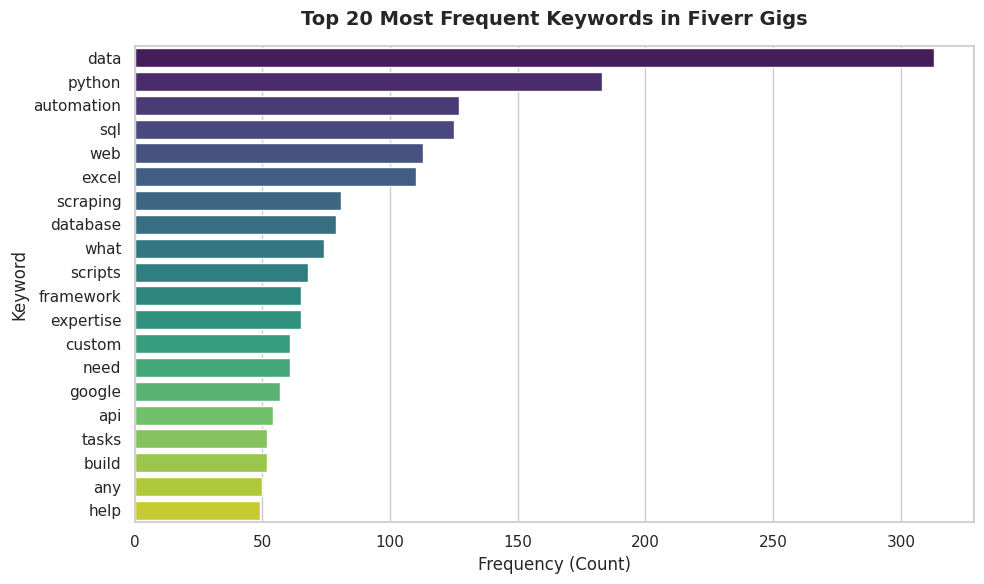

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert our keyword counts into a DataFrame for plotting
keyword_df = pd.DataFrame(top_gig_keywords, columns=['Keyword', 'Frequency'])

# Set up the plot style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Create horizontal bar plot using a vibrant palette
sns.barplot(data=keyword_df, x='Frequency', y='Keyword', hue='Keyword', palette='viridis', legend=False)

plt.title('Top 20 Most Frequent Keywords in Fiverr Gigs', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Frequency (Count)', fontsize=12)
plt.ylabel('Keyword', fontsize=12)

plt.tight_layout()

plt.savefig('portfolio/charts/06_nlp_keyword_analysis.png')

plt.show()


